# Autonomous Energy Optimization Platform (Grids)


## Step 1: Import the libraries we need

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("all libraries loaded")


all libraries loaded


## Step 2: Point the notebook to data folder

In [2]:
base_folder = r"C:\Users\Administrator\Documents\project\DATA_SET"

daily_folder = os.path.join(base_folder, "daily_dataset")
halfhourly_folder = os.path.join(base_folder, "halfhourly_dataset")
hhblock_folder = os.path.join(base_folder, "hhblock_dataset")

house_info_path = os.path.join(base_folder, "informations_households.csv")
acorn_path = os.path.join(base_folder, "acorn_details.csv")
holiday_path = os.path.join(base_folder, "uk_bank_holidays.csv")
weather_daily_path = os.path.join(base_folder, "weather_daily_darksky.csv")
weather_hourly_path = os.path.join(base_folder, "weather_hourly_darksky.csv")

print("paths are set")


paths are set


## Step 3: Load household info and ACORN details

In [3]:
house_info = pd.read_csv(house_info_path)
acorn_info = pd.read_csv(acorn_path, encoding="latin1")

print("household info shape:", house_info.shape)
house_info.head()


household info shape: (5566, 5)


,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


## Step 4: Load the daily energy data

In [4]:
blocks_to_use = 10

all_files = sorted(glob.glob(os.path.join(daily_folder, "block_*.csv")))

if blocks_to_use is not None:
    all_files = all_files[:blocks_to_use]

print("number of daily files we will read:", len(all_files))

daily_list = []
for one_file in all_files:
    small_table = pd.read_csv(one_file)
    daily_list.append(small_table)

daily_data = pd.concat(daily_list, ignore_index=True)

print("daily data shape:", daily_data.shape)
daily_data.head()


number of daily files we will read: 10
daily data shape: (308536, 9)


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000002,2012-10-12,0.1385,0.154304,0.886,46,0.196034,7.098,0.000
1,MAC000002,2012-10-13,0.1800,0.230979,0.933,48,0.192329,11.087,0.076
2,MAC000002,2012-10-14,0.1580,0.275479,1.085,48,0.274647,13.223,0.070
3,MAC000002,2012-10-15,0.1310,0.213688,1.164,48,0.224483,10.257,0.070
4,MAC000002,2012-10-16,0.1450,0.203521,0.991,48,0.184115,9.769,0.087


## Step 5: Load the weather data

In [5]:
weather_data = pd.read_csv(weather_daily_path)
weather_data = weather_data.rename(columns={"time": "day"})
weather_data["day"] = pd.to_datetime(weather_data["day"]).dt.date

print("weather data shape:", weather_data.shape)
weather_data.head()


weather data shape: (882, 32)


,temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,windSpeed,pressure,apparentTemperatureMinTime,...,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase
0,11.96,2011-11-11 23:00:00,123,fog,9.40,2011-11-11 07:00:00,0.79,3.88,1016.08,2011-11-11 07:00:00,...,10.87,2011-11-11 07:12:14,2011-11-11 19:00:00,2011-11-11 11:00:00,Foggy until afternoon.,2011-11-11 19:00:00,6.48,2011-11-11 23:00:00,2011-11-11 19:00:00,0.52
1,8.59,2011-12-11 14:00:00,198,partly-cloudy-day,4.49,2011-12-11 01:00:00,0.56,3.94,1007.71,2011-12-11 02:00:00,...,8.59,2011-12-11 07:57:02,2011-12-11 14:00:00,2011-12-11 12:00:00,Partly cloudy throughout the day.,2011-12-12 07:00:00,0.11,2011-12-11 20:00:00,2011-12-12 08:00:00,0.53
2,10.33,2011-12-27 02:00:00,225,partly-cloudy-day,5.47,2011-12-27 23:00:00,0.85,3.54,1032.76,2011-12-27 22:00:00,...,10.33,2011-12-27 08:07:06,2011-12-27 14:00:00,2011-12-27 00:00:00,Mostly cloudy throughout the day.,2011-12-27 23:00:00,5.59,2011-12-27 02:00:00,2011-12-28 00:00:00,0.10
3,8.07,2011-12-02 23:00:00,232,wind,3.69,2011-12-02 07:00:00,0.32,3.00,1012.12,2011-12-02 07:00:00,...,7.36,2011-12-02 07:46:09,2011-12-02 12:00:00,2011-12-02 10:00:00,Partly cloudy throughout the day and breezy ov...,2011-12-02 19:00:00,0.46,2011-12-02 12:00:00,2011-12-02 19:00:00,0.25
4,8.22,2011-12-24 23:00:00,252,partly-cloudy-night,2.79,2011-12-24 07:00:00,0.37,4.46,1028.17,2011-12-24 07:00:00,...,7.93,2011-12-24 08:06:15,2011-12-24 15:00:00,2011-12-24 13:00:00,Mostly cloudy throughout the day.,2011-12-24 19:00:00,-0.51,2011-12-24 23:00:00,2011-12-24 20:00:00,0.99


## Step 6: Load UK bank holidays

In [6]:
holiday_data = pd.read_csv(holiday_path)
holiday_data = holiday_data.rename(columns={"Bank holidays": "day"})
holiday_data["day"] = pd.to_datetime(holiday_data["day"]).dt.date

holiday_list = set(holiday_data["day"])

print("number of holidays loaded:", len(holiday_list))
holiday_data.head()


number of holidays loaded: 25


,day,Type
0,2012-12-26,Boxing Day
1,2012-12-25,Christmas Day
2,2012-08-27,Summer bank holiday
3,2012-05-06,Queen?s Diamond Jubilee (extra bank holiday)
4,2012-04-06,Spring bank holiday (substitute day)


## Step 7: Clean the data 

In [7]:
daily_data["day"] = pd.to_datetime(daily_data["day"]).dt.date


daily_data = daily_data.dropna(subset=["energy_sum"])

merged_data = daily_data.merge(house_info, on="LCLid", how="left")

merged_data = merged_data.merge(weather_data, on="day", how="left")

weather_columns = ["temperatureMax", "temperatureMin", "humidity", "windSpeed",
                    "pressure", "cloudCover", "visibility", "uvIndex"]

for column in weather_columns:
    if column in merged_data.columns:
        merged_data[column] = merged_data[column].fillna(merged_data[column].mean())

print("merged data shape:", merged_data.shape)
merged_data.head()


merged data shape: (309109, 44)


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,...,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase
0,MAC000002,2012-10-12,0.1385,0.154304,0.886,46,0.196034,7.098,0.000,Std,...,11.53,2012-10-13 06:22:42,2012-10-13 14:00:00,2012-10-13 12:00:00,Partly cloudy until evening.,2012-10-14 07:00:00,4.01,2012-10-13 14:00:00,2012-10-14 06:00:00,0.92
1,MAC000002,2012-10-13,0.1800,0.230979,0.933,48,0.192329,11.087,0.076,Std,...,12.32,2012-10-14 06:24:23,2012-10-14 14:00:00,2012-10-14 12:00:00,"Partly cloudy starting in the afternoon, conti...",2012-10-15 03:00:00,1.64,2012-10-14 14:00:00,2012-10-15 04:00:00,0.96
2,MAC000002,2012-10-14,0.1580,0.275479,1.085,48,0.274647,13.223,0.070,Std,...,13.03,2012-10-15 06:26:05,2012-10-15 14:00:00,2012-10-15 09:00:00,Partly cloudy throughout the day.,2012-10-16 05:00:00,2.83,2012-10-15 14:00:00,2012-10-16 06:00:00,0.99
3,MAC000002,2012-10-15,0.1310,0.213688,1.164,48,0.224483,10.257,0.070,Std,...,14.74,2012-10-16 06:27:48,2012-10-16 14:00:00,2012-10-16 09:00:00,Partly cloudy throughout the day and breezy un...,2012-10-16 23:00:00,7.15,2012-10-16 14:00:00,2012-10-16 23:00:00,0.03
4,MAC000002,2012-10-16,0.1450,0.203521,0.991,48,0.184115,9.769,0.087,Std,...,16.60,2012-10-17 06:29:30,2012-10-17 13:00:00,2012-10-17 09:00:00,Partly cloudy throughout the day.,2012-10-18 07:00:00,7.41,2012-10-17 13:00:00,2012-10-18 07:00:00,0.07


## Step 8: Explore the data (EDA)

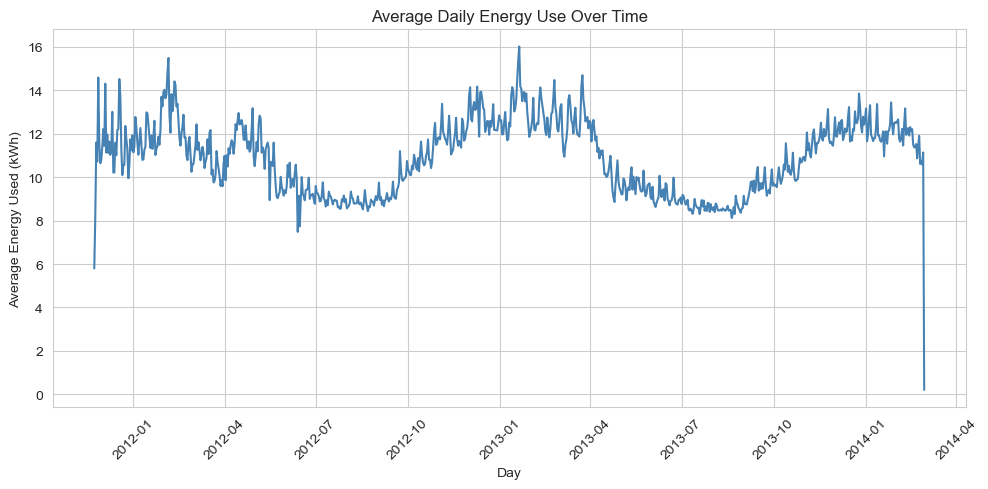

In [8]:
daily_trend = merged_data.groupby("day")["energy_sum"].mean().reset_index()

plt.plot(daily_trend["day"], daily_trend["energy_sum"], color="steelblue")
plt.title("Average Daily Energy Use Over Time")
plt.xlabel("Day")
plt.ylabel("Average Energy Used (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


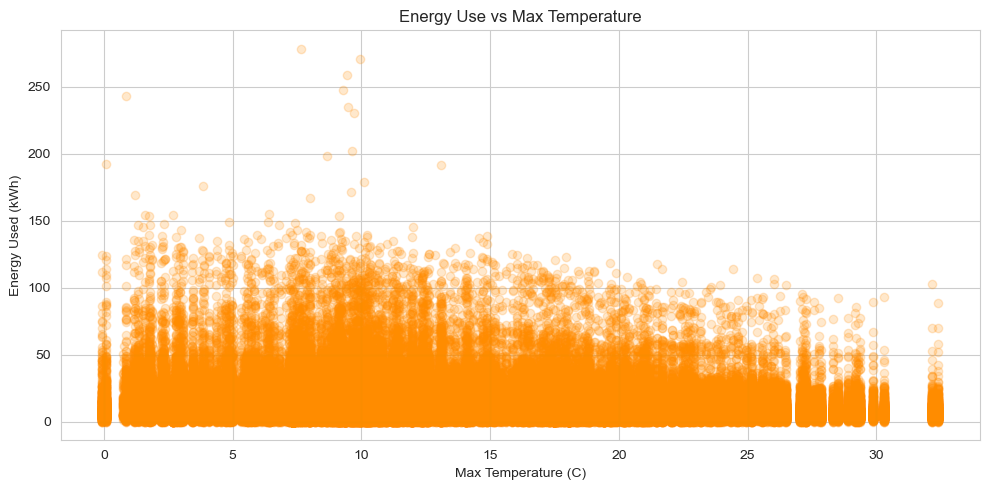

In [9]:
plt.scatter(merged_data["temperatureMax"], merged_data["energy_sum"],
            alpha=0.2, color="darkorange")
plt.title("Energy Use vs Max Temperature")
plt.xlabel("Max Temperature (C)")
plt.ylabel("Energy Used (kWh)")
plt.tight_layout()
plt.show()


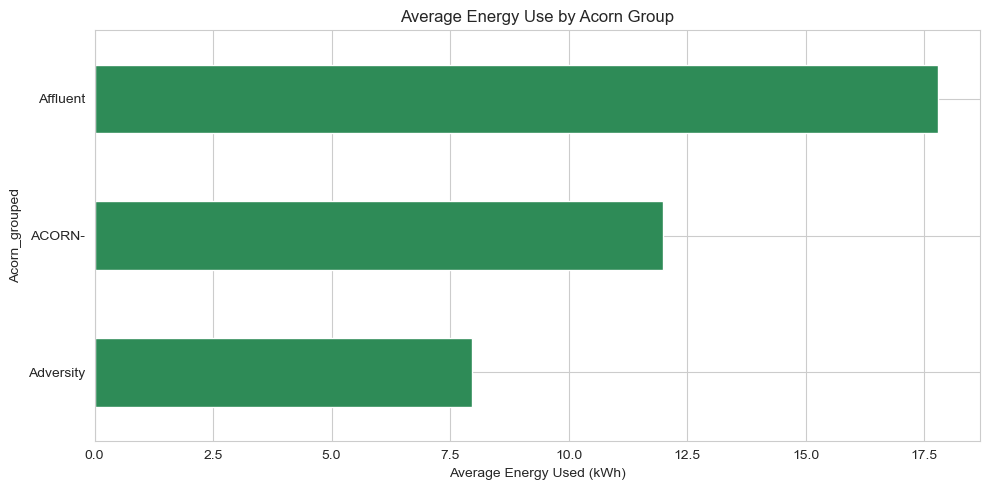

In [10]:
group_usage = merged_data.groupby("Acorn_grouped")["energy_sum"].mean().sort_values()

group_usage.plot(kind="barh", color="seagreen")
plt.title("Average Energy Use by Acorn Group")
plt.xlabel("Average Energy Used (kWh)")
plt.tight_layout()
plt.show()


## Step 9: Feature engineering

Now our model can learn from:
- day of the week
- weekend flag
- holiday flag
- month (for seasons)
- yesterday's energy use


In [11]:
merged_data["day"] = pd.to_datetime(merged_data["day"])

merged_data["day_of_week"] = merged_data["day"].dt.dayofweek
merged_data["is_weekend"] = merged_data["day_of_week"].isin([5, 6]).astype(int)
merged_data["month"] = merged_data["day"].dt.month
merged_data["is_holiday"] = merged_data["day"].dt.date.isin(holiday_list).astype(int)
merged_data = merged_data.sort_values(["LCLid", "day"])
merged_data["energy_yesterday"] = merged_data.groupby("LCLid")["energy_sum"].shift(1)

merged_data["energy_yesterday"] = merged_data["energy_yesterday"].fillna(
    merged_data.groupby("LCLid")["energy_sum"].transform("mean")
)

print("features ready")
merged_data[["day", "day_of_week", "is_weekend", "month",
             "is_holiday", "energy_yesterday"]].head()


features ready


,day,day_of_week,is_weekend,month,is_holiday,energy_yesterday
0,2012-10-12,4,0,10,0,12.056532
1,2012-10-13,5,1,10,0,7.098000
2,2012-10-14,6,1,10,0,11.087000
3,2012-10-15,0,0,10,0,13.223000
4,2012-10-16,1,0,10,0,10.257000


## Step 10: Prepare the data for the model

In [12]:
feature_columns = ["day_of_week", "is_weekend", "month", "is_holiday",
                    "energy_yesterday", "temperatureMax", "temperatureMin",
                    "humidity", "windSpeed", "cloudCover"]

model_data = merged_data.dropna(subset=feature_columns + ["energy_sum"])

x = model_data[feature_columns]
y = model_data["energy_sum"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("training rows:", train_x.shape[0])
print("testing rows:", test_x.shape[0])


training rows: 247287
testing rows: 61822


## Step 11: Linear Regression Model


In [13]:
baseline_model = LinearRegression()
baseline_model.fit(train_x, train_y)

baseline_prediction = baseline_model.predict(test_x)

baseline_mae = mean_absolute_error(test_y, baseline_prediction)
baseline_rmse = mean_squared_error(test_y, baseline_prediction) ** 0.5
baseline_r2 = r2_score(test_y, baseline_prediction)

print("Baseline Linear Regression")
print("MAE :", round(baseline_mae, 3))
print("RMSE:", round(baseline_rmse, 3))
print("R2  :", round(baseline_r2, 3))


Baseline Linear Regression
MAE : 2.379
RMSE: 4.359
R2  : 0.857


## Step 12: Random Forest model

In [14]:
forecast_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(train_x, train_y)

forecast_prediction = forecast_model.predict(test_x)

forecast_mae = mean_absolute_error(test_y, forecast_prediction)
forecast_rmse = mean_squared_error(test_y, forecast_prediction) ** 0.5
forecast_r2 = r2_score(test_y, forecast_prediction)

print("Random Forest Forecast Model")
print("MAE :", round(forecast_mae, 3))
print("RMSE:", round(forecast_rmse, 3))
print("R2  :", round(forecast_r2, 3))


Random Forest Forecast Model
MAE : 2.356
RMSE: 4.358
R2  : 0.857


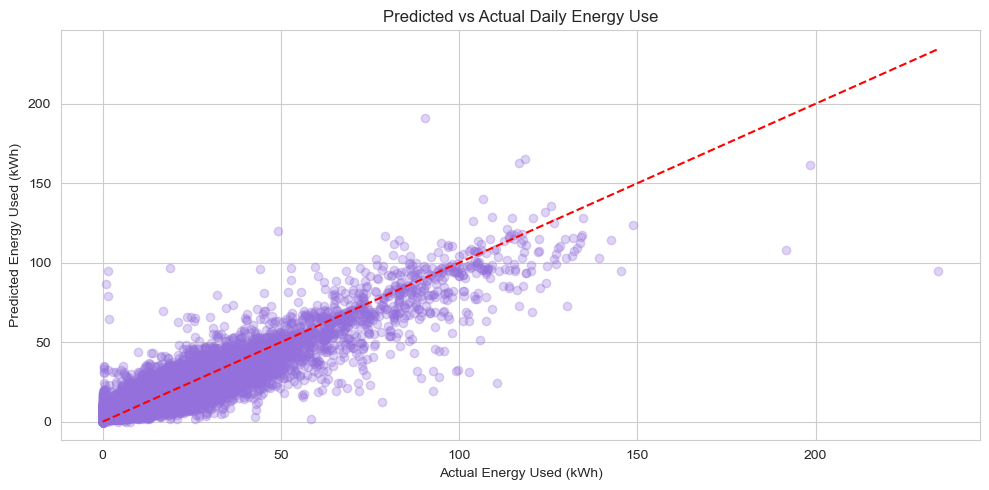

In [15]:
plt.scatter(test_y, forecast_prediction, alpha=0.3, color="mediumpurple")
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()],
         color="red", linestyle="--")
plt.title("Predicted vs Actual Daily Energy Use")
plt.xlabel("Actual Energy Used (kWh)")
plt.ylabel("Predicted Energy Used (kWh)")
plt.tight_layout()
plt.show()


## Step 13: What matters most to the model?

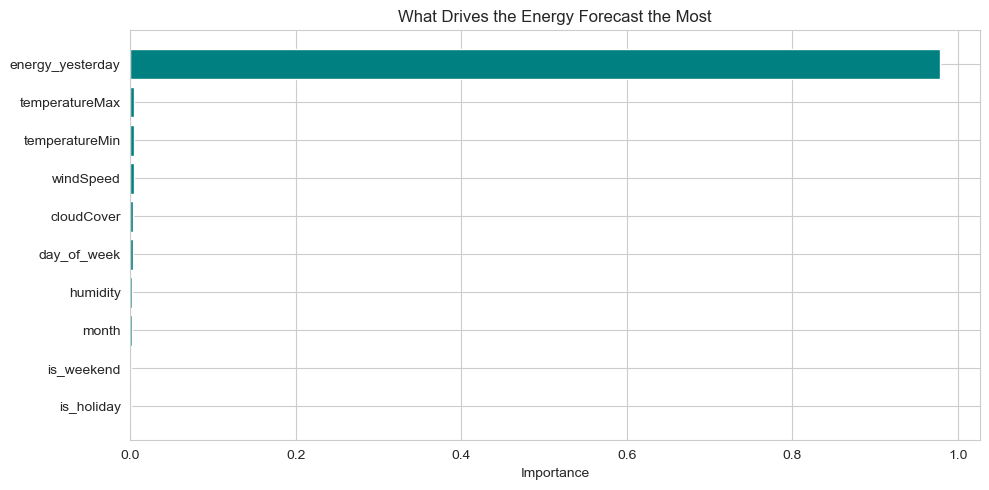

In [16]:
importance_table = pd.DataFrame({
    "feature": feature_columns,
    "importance": forecast_model.feature_importances_
}).sort_values("importance", ascending=True)

plt.barh(importance_table["feature"], importance_table["importance"], color="teal")
plt.title("What Drives the Energy Forecast the Most")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Step 14: Group households into usage patterns

In [17]:
house_profile = merged_data.groupby("LCLid").agg(
    avg_energy=("energy_sum", "mean"),
    energy_spread=("energy_sum", "std"),
    weekend_energy=("energy_sum", lambda values: values[merged_data.loc[values.index, "is_weekend"] == 1].mean()),
    weekday_energy=("energy_sum", lambda values: values[merged_data.loc[values.index, "is_weekend"] == 0].mean()),
).dropna()

print("household profile shape:", house_profile.shape)
house_profile.head()


household profile shape: (500, 4)


,avg_energy,energy_spread,weekend_energy,weekday_energy
LCLid,,,,
MAC000002,12.056532,4.501264,12.799262,11.758205
MAC000077,5.839753,1.084196,5.736624,5.881360
MAC000090,16.236899,6.925401,16.611772,16.086950
MAC000092,5.067188,2.606858,3.944254,5.516362
MAC000133,21.856063,5.665894,23.699526,21.114844


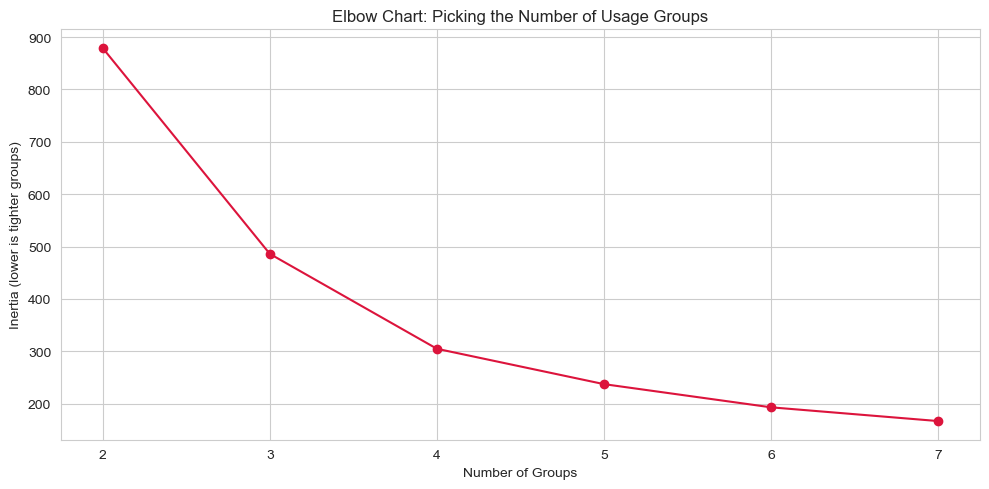

In [18]:
scaler = StandardScaler()
scaled_profile = scaler.fit_transform(house_profile)

inertia_scores = []
group_options = range(2, 8)

for k in group_options:
    test_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    test_model.fit(scaled_profile)
    inertia_scores.append(test_model.inertia_)

plt.plot(list(group_options), inertia_scores, marker="o", color="crimson")
plt.title("Elbow Chart: Picking the Number of Usage Groups")
plt.xlabel("Number of Groups")
plt.ylabel("Inertia (lower is tighter groups)")
plt.tight_layout()
plt.show()


In [19]:
number_of_groups = 4
cluster_model = KMeans(n_clusters=number_of_groups, random_state=42, n_init=10)
house_profile["usage_group"] = cluster_model.fit_predict(scaled_profile)
print(house_profile["usage_group"].value_counts())
house_profile.head()


usage_group
0    304
3    156
2     32
1      8
Name: count, dtype: int64


,avg_energy,energy_spread,weekend_energy,weekday_energy,usage_group
LCLid,,,,,
MAC000002,12.056532,4.501264,12.799262,11.758205,3
MAC000077,5.839753,1.084196,5.736624,5.881360,0
MAC000090,16.236899,6.925401,16.611772,16.086950,3
MAC000092,5.067188,2.606858,3.944254,5.516362,0
MAC000133,21.856063,5.665894,23.699526,21.114844,3


In [20]:
group_summary = house_profile.groupby("usage_group").mean()
group_summary


,avg_energy,energy_spread,weekend_energy,weekday_energy
usage_group,,,,
0,5.747831,1.891023,5.957807,5.663654
1,63.940262,24.129513,65.765145,63.205461
2,29.068835,13.306262,29.367322,28.948307
3,14.595250,5.068647,15.327285,14.302127


## Step 15: Find the peak usage hours

In [21]:
sample_file = sorted(glob.glob(os.path.join(halfhourly_folder, "block_*.csv")))[0]
halfhourly_sample = pd.read_csv(sample_file)

print("sample half-hourly shape:", halfhourly_sample.shape)
halfhourly_sample.head()


sample half-hourly shape: (1222670, 3)


,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0


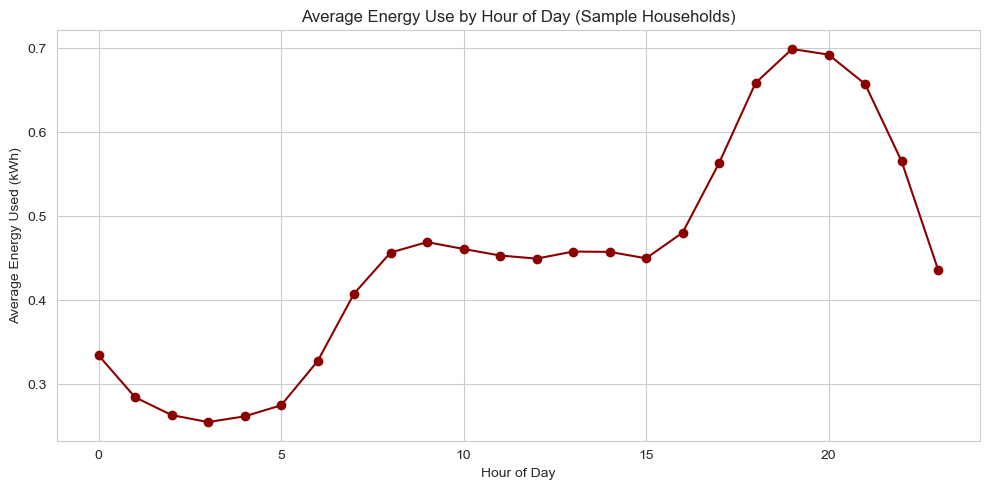

The peak usage hour in this sample is around 19 :00


In [22]:
time_column = "tstp" if "tstp" in halfhourly_sample.columns else halfhourly_sample.columns[1]

halfhourly_sample[time_column] = pd.to_datetime(halfhourly_sample[time_column])
halfhourly_sample["hour"] = halfhourly_sample[time_column].dt.hour

energy_column = [c for c in halfhourly_sample.columns if "energy" in c.lower()][0]
halfhourly_sample[energy_column] = pd.to_numeric(halfhourly_sample[energy_column], errors="coerce")

hourly_pattern = halfhourly_sample.groupby("hour")[energy_column].mean()

hourly_pattern.plot(kind="line", marker="o", color="darkred")
plt.title("Average Energy Use by Hour of Day (Sample Households)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Used (kWh)")
plt.tight_layout()
plt.show()

peak_hour = hourly_pattern.idxmax()
print("The peak usage hour in this sample is around", peak_hour, ":00")


## Step 16: simple optimization

In [23]:
def build_energy_tips(peak_hour, group_summary, forecast_mae):
    tips = []

    tips.append(
        f"Peak demand happens around {peak_hour}:00. Shifting heavy appliances "
        f"(washing machine, dishwasher, EV charging) away from this hour "
        f"can help reduce strain on the grid and may lower costs on dynamic tariffs."
    )

    heavy_group = group_summary["avg_energy"].idxmax()
    light_group = group_summary["avg_energy"].idxmin()

    tips.append(
        f"Usage group {heavy_group} uses the most energy on average. "
        f"These households are good targets for efficiency programs "
        f"(insulation checks, smart thermostats, appliance upgrades)."
    )

    tips.append(
        f"Usage group {light_group} already uses energy efficiently and "
        f"could be a reference group to compare others against."
    )

    tips.append(
        f"Our forecast model is accurate to within about {round(forecast_mae, 2)} kWh "
        f"per day on average, which is good enough to plan next-day grid load "
        f"and warn high-usage households in advance."
    )

    weekend_vs_weekday = group_summary["weekend_energy"].mean() - group_summary["weekday_energy"].mean()
    if weekend_vs_weekday > 0:
        tips.append(
            "On average, households use more energy on weekends than weekdays. "
            "Weekend-specific pricing or reminders could help flatten demand."
        )
    else:
        tips.append(
            "On average, households use more energy on weekdays than weekends. "
            "This lines up with work-from-home and evening routines."
        )

    return tips


energy_tips = build_energy_tips(peak_hour, group_summary, forecast_mae)

print("ENERGY OPTIMIZATION INSIGHTS")
print("-" * 40)
for i, tip in enumerate(energy_tips, start=1):
    print(f"{i}. {tip}")


ENERGY OPTIMIZATION INSIGHTS
----------------------------------------
1. Peak demand happens around 19:00. Shifting heavy appliances (washing machine, dishwasher, EV charging) away from this hour can help reduce strain on the grid and may lower costs on dynamic tariffs.
2. Usage group 1 uses the most energy on average. These households are good targets for efficiency programs (insulation checks, smart thermostats, appliance upgrades).
3. Usage group 0 already uses energy efficiently and could be a reference group to compare others against.
4. Our forecast model is accurate to within about 2.36 kWh per day on average, which is good enough to plan next-day grid load and warn high-usage households in advance.
5. On average, households use more energy on weekends than weekdays. Weekend-specific pricing or reminders could help flatten demand.


## Step 17: Save the model and the results

Finally, we save the trained model and the cleaned data so they can be
reused later without repeating all the steps above.


In [1]:
output_folder = r"C:\Users\Administrator\Documents\Autonomous Energy Optimization Platform for Smart Grid\outputs"
os.makedirs(output_folder, exist_ok=True)

joblib.dump(forecast_model, os.path.join("outputs", "energy_forecast_model.pkl"))
merged_data.to_csv(os.path.join("outputs", "cleaned_merged_energy_data.csv"), index=False)
house_profile.to_csv(os.path.join("outputs", "household_usage_groups.csv"))

print("model and data saved inside the 'outputs' folder")
print(os.getcwd())


NameError: name 'os' is not defined

## Summary:
1. I  pulled together smart meter readings, weather, holidays, and household
   details into one clean table.
2. I looked at the data with simple charts to understand it.
3. I built two models to forecast daily energy use: a simple baseline and a
   stronger Random Forest model.
4. I grouped households into usage patterns using clustering.
5. I found the peak usage hour from half-hourly data.
6. I turned all of that into plain-English optimization tips.
7. I saved the model and results so they can be reused into a
   dashboard or app later.